In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,FALSE
1,1,1,2010-02-12,46039.49,TRUE
2,1,1,2010-02-19,41595.55,FALSE
3,1,1,2010-02-26,19403.54,FALSE
4,1,1,2010-03-05,21827.90,FALSE


In [4]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,FALSE
1,1,1,2012-11-09,FALSE
2,1,1,2012-11-16,FALSE
3,1,1,2012-11-23,TRUE
4,1,1,2012-11-30,FALSE


In [5]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [6]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NA,NA,NA,NA,NA,211.0963582,8.106,FALSE
1,1,2010-02-12,38.51,2.548,NA,NA,NA,NA,NA,211.2421698,8.106,TRUE
2,1,2010-02-19,39.93,2.514,NA,NA,NA,NA,NA,211.2891429,8.106,FALSE
3,1,2010-02-26,46.63,2.561,NA,NA,NA,NA,NA,211.3196429,8.106,FALSE
4,1,2010-03-05,46.50,2.625,NA,NA,NA,NA,NA,211.3501429,8.106,FALSE


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373410 entries, 0 to 373409
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Store          373410 non-null  int64  
 1    Dept          373410 non-null  int64  
 2    Date          373410 non-null  object 
 3    Weekly_Sales  373410 non-null  float64
 4    IsHoliday     373409 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.2+ MB


In [8]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Store          8190 non-null   int64  
 1    Date          8190 non-null   object 
 2    Temperature   8190 non-null   float64
 3    Fuel_Price    8190 non-null   float64
 4    MarkDown1     8190 non-null   object 
 5    MarkDown2     8190 non-null   object 
 6    MarkDown3     8190 non-null   object 
 7    MarkDown4     8190 non-null   object 
 8    MarkDown5     8190 non-null   object 
 9    CPI           8190 non-null   object 
 10   Unemployment  8190 non-null   object 
 11   IsHoliday     8190 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 767.9+ KB


In [9]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1    Type   45 non-null     object
 2    Size   45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [10]:
features.describe()

,Store,Temperature,Fuel_Price
count,8190.000000,8190.000000,8190.000000
mean,23.000000,59.356198,3.405992
std,12.987966,18.678607,0.431337
min,1.000000,-7.290000,2.472000
25%,12.000000,45.902500,3.041000
50%,23.000000,60.710000,3.513000
75%,34.000000,73.880000,3.743000
max,45.000000,101.950000,4.468000


In [11]:
for df in [train, test, features, stores]:
    df.columns = df.columns.str.strip()

In [12]:
print(train.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']


In [13]:
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (373410, 5)
Test shape: (115064, 4)


In [14]:
def clean_markdown(df):
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    for col in markdown_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().replace('NA', '0').replace('', '0')
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

train = clean_markdown(train)
test = clean_markdown(test)
features = clean_markdown(features)

In [15]:
features_ext = pd.merge(features, stores, on='Store', how='left')
train_df = pd.merge(train, features_ext, on=['Store', 'Date', 'IsHoliday'], how='left')
test_df = pd.merge(test, features_ext, on=['Store', 'Date', 'IsHoliday'], how='left')

print(f"Train after merge: {train_df.shape}")
print(f"Test after merge: {test_df.shape}")

Train after merge: (373410, 16)
Test after merge: (115064, 15)


In [16]:
train_df.isna().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,1
Temperature,1
Fuel_Price,1
MarkDown1,1
MarkDown2,1
MarkDown3,1


In [17]:
train_df.duplicated().sum()

np.int64(0)

In [18]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


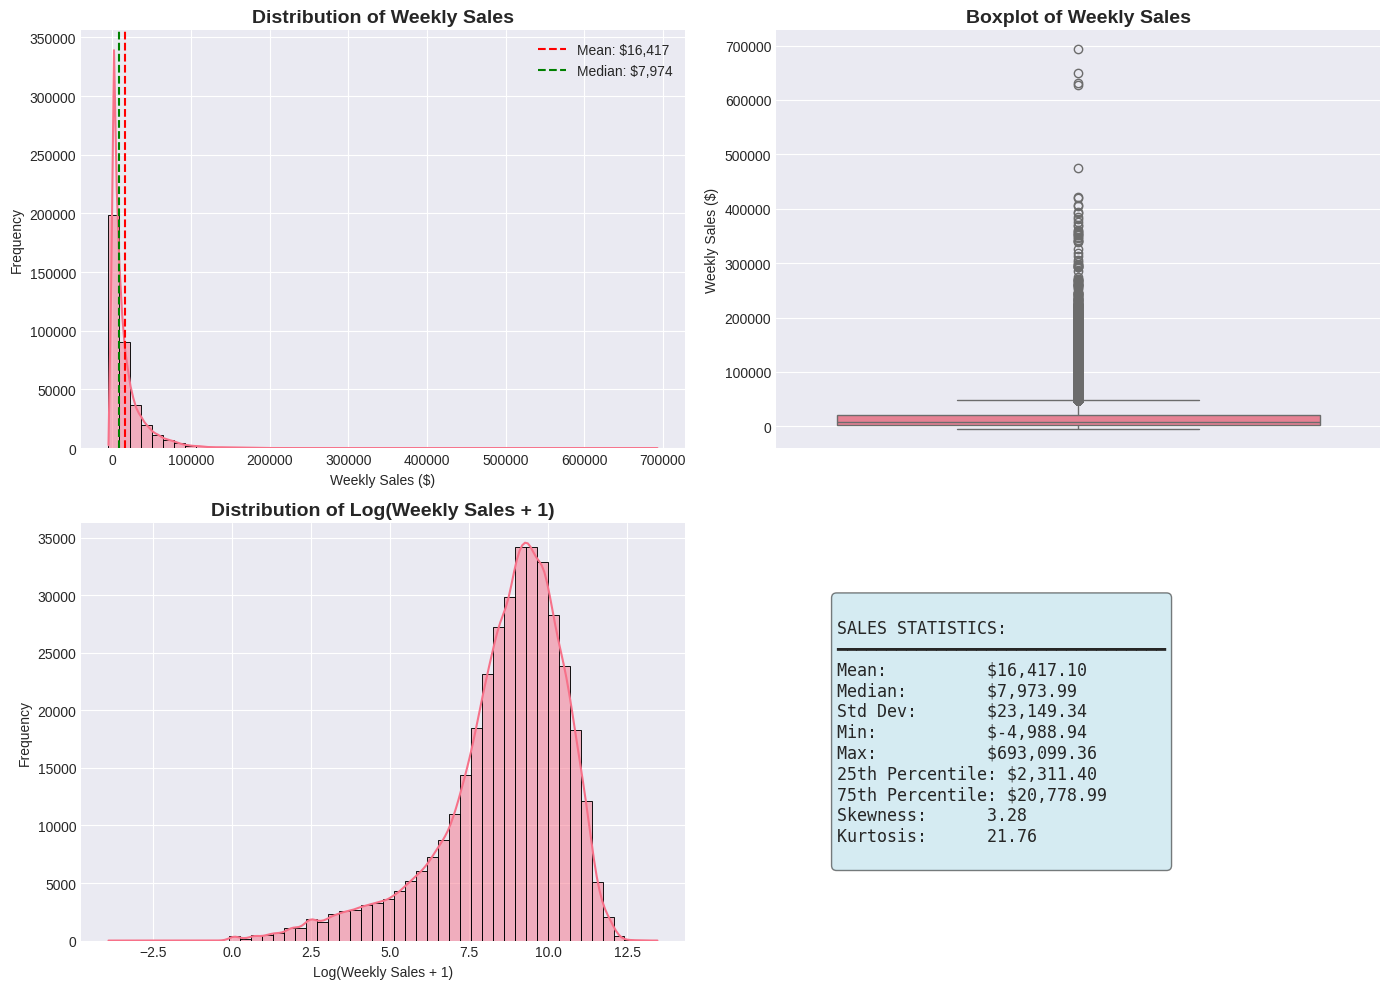

In [19]:
#SALES DISTRIBUTION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
ax1 = axes[0, 0]
sns.histplot(train['Weekly_Sales'], bins=50, kde=True, ax=ax1)
ax1.set_title('Distribution of Weekly Sales', fontsize=14, fontweight='bold')
ax1.set_xlabel('Weekly Sales ($)')
ax1.set_ylabel('Frequency')
ax1.axvline(train['Weekly_Sales'].mean(), color='red', linestyle='--', label=f'Mean: ${train["Weekly_Sales"].mean():,.0f}')
ax1.axvline(train['Weekly_Sales'].median(), color='green', linestyle='--', label=f'Median: ${train["Weekly_Sales"].median():,.0f}')
ax1.legend()

# Boxplot
ax2 = axes[0, 1]
sns.boxplot(y=train['Weekly_Sales'], ax=ax2)
ax2.set_title('Boxplot of Weekly Sales', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weekly Sales ($)')

# Log scale histogram
ax3 = axes[1, 0]
sns.histplot(np.log1p(train['Weekly_Sales']), bins=50, kde=True, ax=ax3)
ax3.set_title('Distribution of Log(Weekly Sales + 1)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Log(Weekly Sales + 1)')
ax3.set_ylabel('Frequency')

# Stats summary
ax4 = axes[1, 1]
ax4.axis('off')
stats_text = f"""
SALES STATISTICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean:          ${train['Weekly_Sales'].mean():,.2f}
Median:        ${train['Weekly_Sales'].median():,.2f}
Std Dev:       ${train['Weekly_Sales'].std():,.2f}
Min:           ${train['Weekly_Sales'].min():,.2f}
Max:           ${train['Weekly_Sales'].max():,.2f}
25th Percentile: ${train['Weekly_Sales'].quantile(0.25):,.2f}
75th Percentile: ${train['Weekly_Sales'].quantile(0.75):,.2f}
Skewness:      {train['Weekly_Sales'].skew():.2f}
Kurtosis:      {train['Weekly_Sales'].kurtosis():.2f}
"""
ax4.text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

/tmp/ipykernel_549/3587276073.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(day_names)


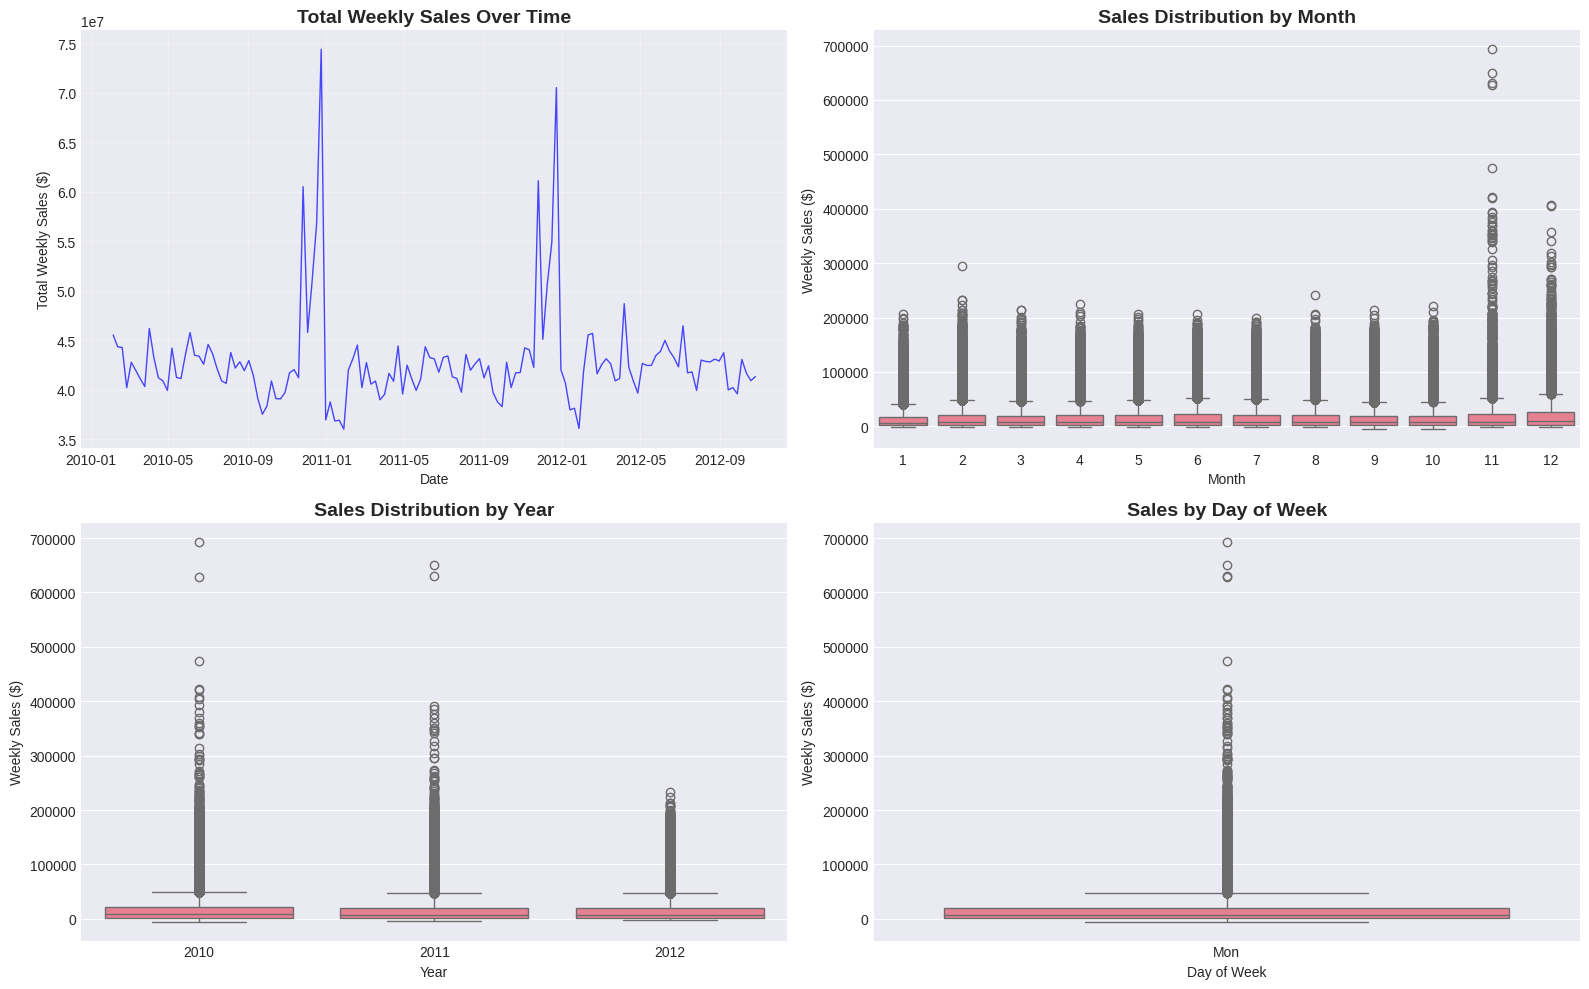

In [20]:
#SALES OVER TIME
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Overall sales trend
store_weekly = train.groupby('Date')['Weekly_Sales'].sum().reset_index()
ax1 = axes[0, 0]
ax1.plot(store_weekly['Date'], store_weekly['Weekly_Sales'], linewidth=1, color='blue', alpha=0.7)
ax1.set_title('Total Weekly Sales Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Weekly Sales ($)')
ax1.grid(True, alpha=0.3)

# Sales by month (boxplot)
train['Month'] = train['Date'].dt.month
ax2 = axes[0, 1]
sns.boxplot(x='Month', y='Weekly_Sales', data=train, ax=ax2)
ax2.set_title('Sales Distribution by Month', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Weekly Sales ($)')

# Sales by year
train['Year'] = train['Date'].dt.year
ax3 = axes[1, 0]
sns.boxplot(x='Year', y='Weekly_Sales', data=train, ax=ax3)
ax3.set_title('Sales Distribution by Year', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Weekly Sales ($)')

# Sales by day of week
train['DayOfWeek'] = train['Date'].dt.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax4 = axes[1, 1]
sns.boxplot(x='DayOfWeek', y='Weekly_Sales', data=train, ax=ax4)
ax4.set_title('Sales by Day of Week', fontsize=14, fontweight='bold')
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Weekly Sales ($)')
ax4.set_xticklabels(day_names)

plt.tight_layout()
plt.show()


HOLIDAY IMPACT ANALYSIS

Sales Statistics:
   Non-Holiday (0):  $16,331.00
   Holiday (1):      $17,554.51
   Difference:       $1,223.51
   Percentage Increase: 7.5%

Data Count:
   Non-Holiday rows: 347,134
   Holiday rows:     26,276
   Holiday %:        7.0%


/tmp/ipykernel_549/3885973128.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([non_holiday_data, holiday_data], labels=['Non-Holiday', 'Holiday'])


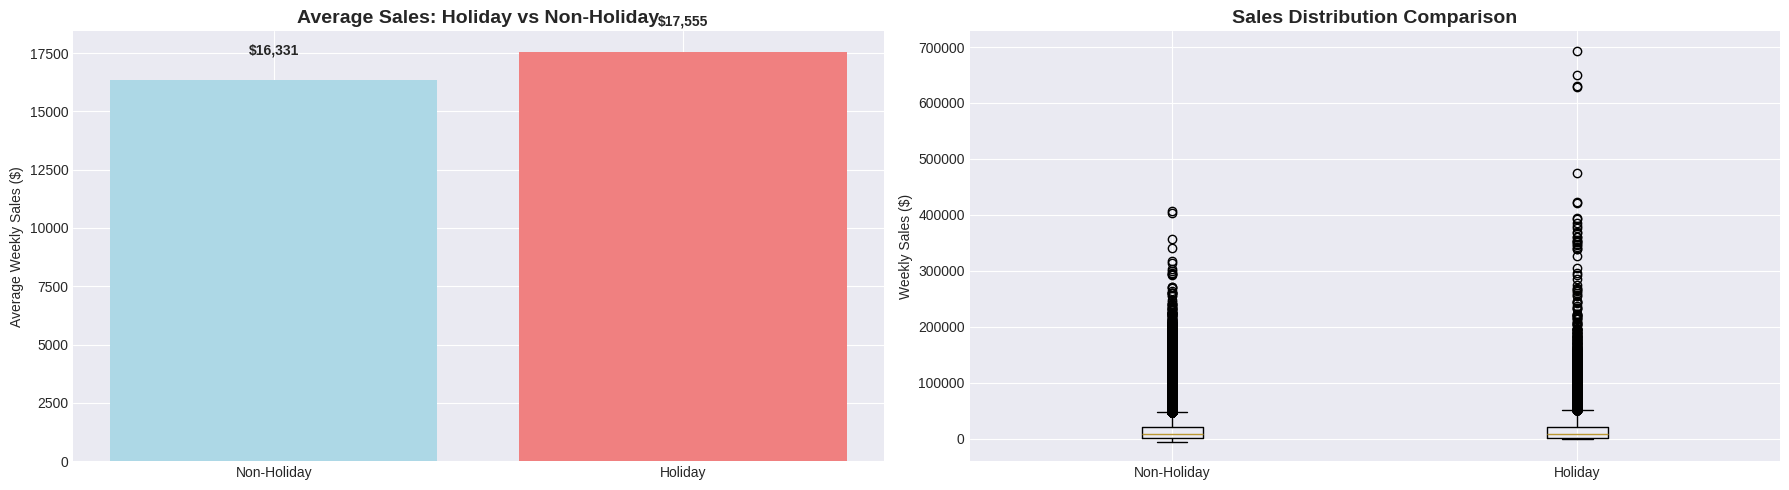

,IsHoliday_Num
0,0
1,1
2,0
3,0
4,0
...,...
373405,0
373406,1
373407,0
373408,0


In [21]:
#HOLIDAY ANALYSIS
print("\n" + "="*60)
print("HOLIDAY IMPACT ANALYSIS")
print("="*60)

# Clean holiday column (remove spaces)
train['IsHoliday'] = train['IsHoliday'].astype(str).str.strip()

# Convert to numeric
train['IsHoliday_Num'] = train['IsHoliday'].map({'TRUE': 1, 'FALSE': 0}).fillna(0).astype(int)

# Calculate statistics
holiday_stats = train.groupby('IsHoliday_Num')['Weekly_Sales'].mean()
holiday_counts = train['IsHoliday_Num'].value_counts()

print(f"\nSales Statistics:")
print(f"   Non-Holiday (0):  ${holiday_stats[0]:,.2f}")
print(f"   Holiday (1):      ${holiday_stats[1]:,.2f}")
print(f"   Difference:       ${holiday_stats[1] - holiday_stats[0]:,.2f}")

holiday_impact = ((holiday_stats[1] / holiday_stats[0]) - 1) * 100
print(f"   Percentage Increase: {holiday_impact:.1f}%")

print(f"\nData Count:")
print(f"   Non-Holiday rows: {holiday_counts[0]:,}")
print(f"   Holiday rows:     {holiday_counts[1]:,}")
print(f"   Holiday %:        {holiday_counts[1] / len(train) * 100:.1f}%")

# Holiday Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Bar chart
ax1 = axes[0]
labels = ['Non-Holiday', 'Holiday']
values = [holiday_stats[0], holiday_stats[1]]
bars = ax1.bar(labels, values, color=['lightblue', 'lightcoral'])
ax1.set_title('Average Sales: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Weekly Sales ($)')
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

# 2. Boxplot comparison
ax2 = axes[1]
holiday_data = train[train['IsHoliday_Num'] == 1]['Weekly_Sales']
non_holiday_data = train[train['IsHoliday_Num'] == 0]['Weekly_Sales']
ax2.boxplot([non_holiday_data, holiday_data], labels=['Non-Holiday', 'Holiday'])
ax2.set_title('Sales Distribution Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weekly Sales ($)')


plt.tight_layout()
plt.show()
train['IsHoliday_Num']


STORE ANALYSIS


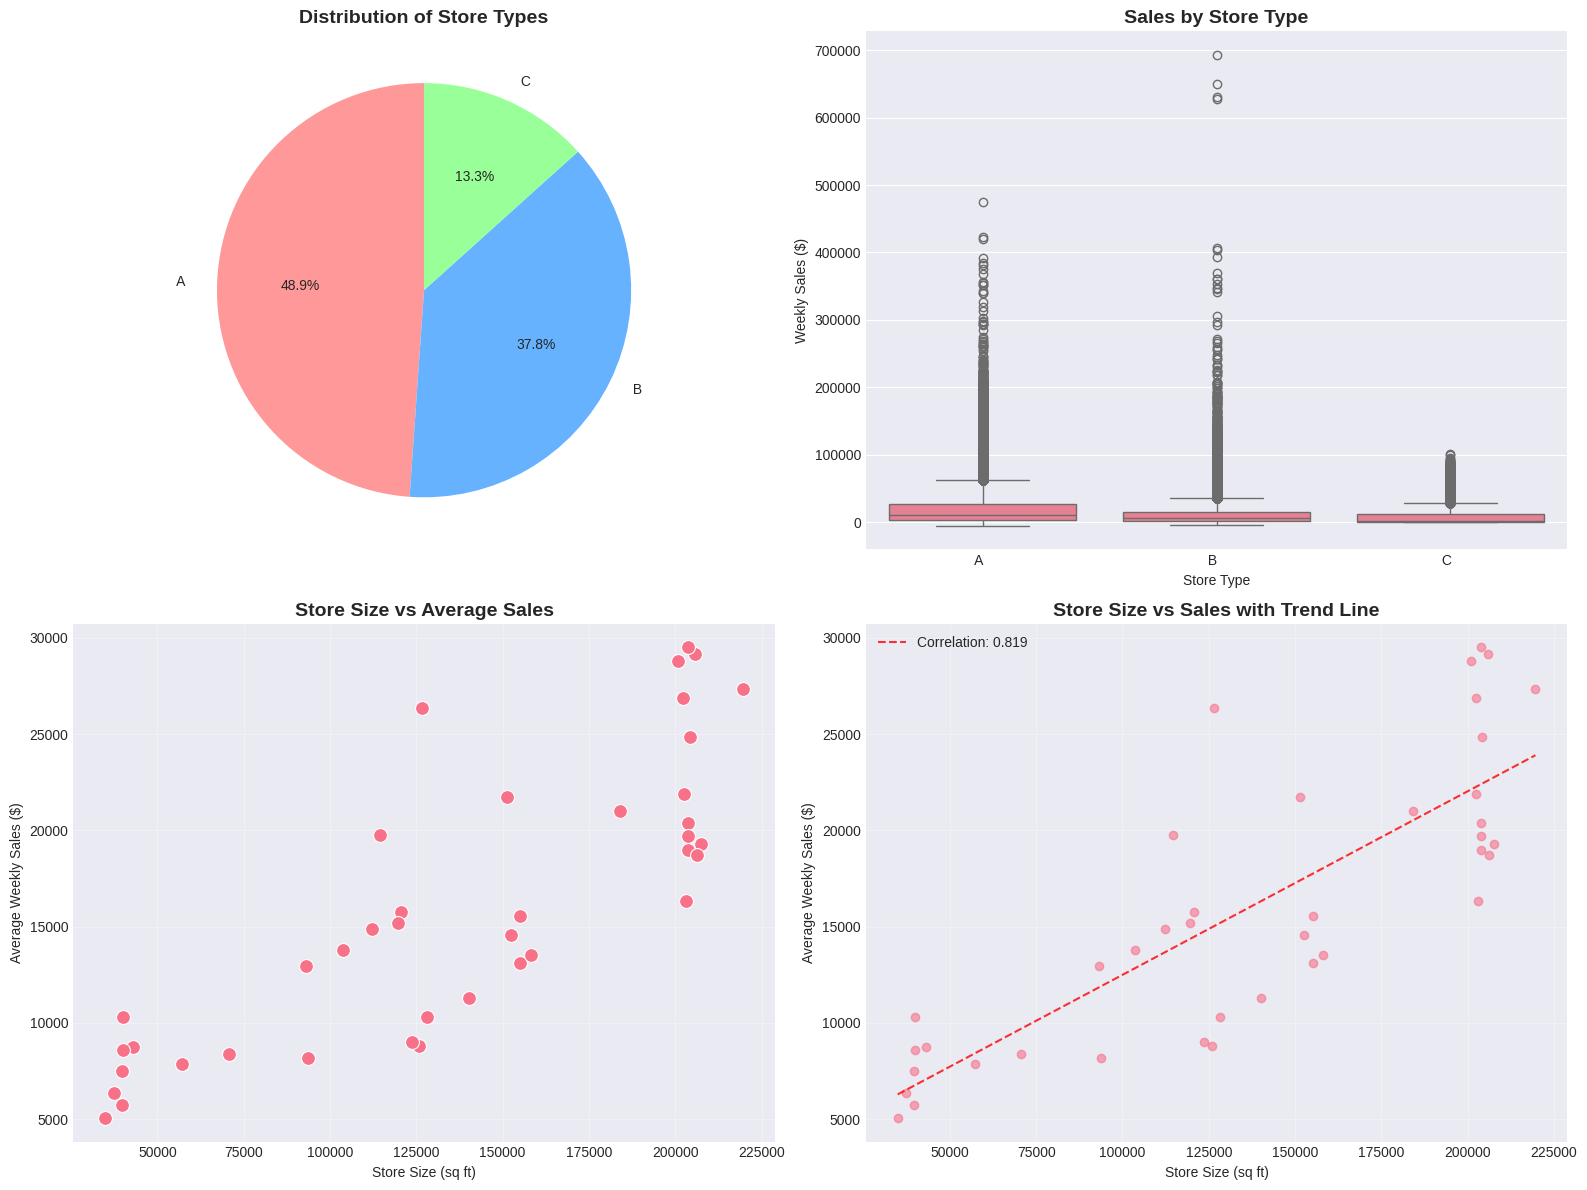

In [22]:
print("\n" + "="*60)
print("STORE ANALYSIS")
print("="*60)

# Merge stores data for analysis


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Store types distribution
type_counts = stores['Type'].value_counts()
ax1 = axes[0, 0]
colors = ['#FF9999', '#66B2FF', '#99FF99']
ax1.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Distribution of Store Types', fontsize=14, fontweight='bold')

# Sales by store type
ax2 = axes[0, 1]
sns.boxplot(x='Type', y='Weekly_Sales', data=train_df, ax=ax2)
ax2.set_title('Sales by Store Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Store Type')
ax2.set_ylabel('Weekly Sales ($)')

# Store size vs sales
ax3 = axes[1, 0]
store_avg = train_df.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'Size': 'first'
}).reset_index()
sns.scatterplot(x='Size', y='Weekly_Sales', data=store_avg, ax=ax3, s=100)
ax3.set_title('Store Size vs Average Sales', fontsize=14, fontweight='bold')
ax3.set_xlabel('Store Size (sq ft)')
ax3.set_ylabel('Average Weekly Sales ($)')
ax3.grid(True, alpha=0.3)

# Correlation with size
ax4 = axes[1, 1]
correlation = store_avg['Size'].corr(store_avg['Weekly_Sales'])
ax4.scatter(store_avg['Size'], store_avg['Weekly_Sales'], alpha=0.6)
# Add trend line
z = np.polyfit(store_avg['Size'], store_avg['Weekly_Sales'], 1)
p = np.poly1d(z)
ax4.plot(store_avg['Size'].sort_values(), p(store_avg['Size'].sort_values()),
         "r--", alpha=0.8, label=f'Correlation: {correlation:.3f}')
ax4.set_title('Store Size vs Sales with Trend Line', fontsize=14, fontweight='bold')
ax4.set_xlabel('Store Size (sq ft)')
ax4.set_ylabel('Average Weekly Sales ($)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

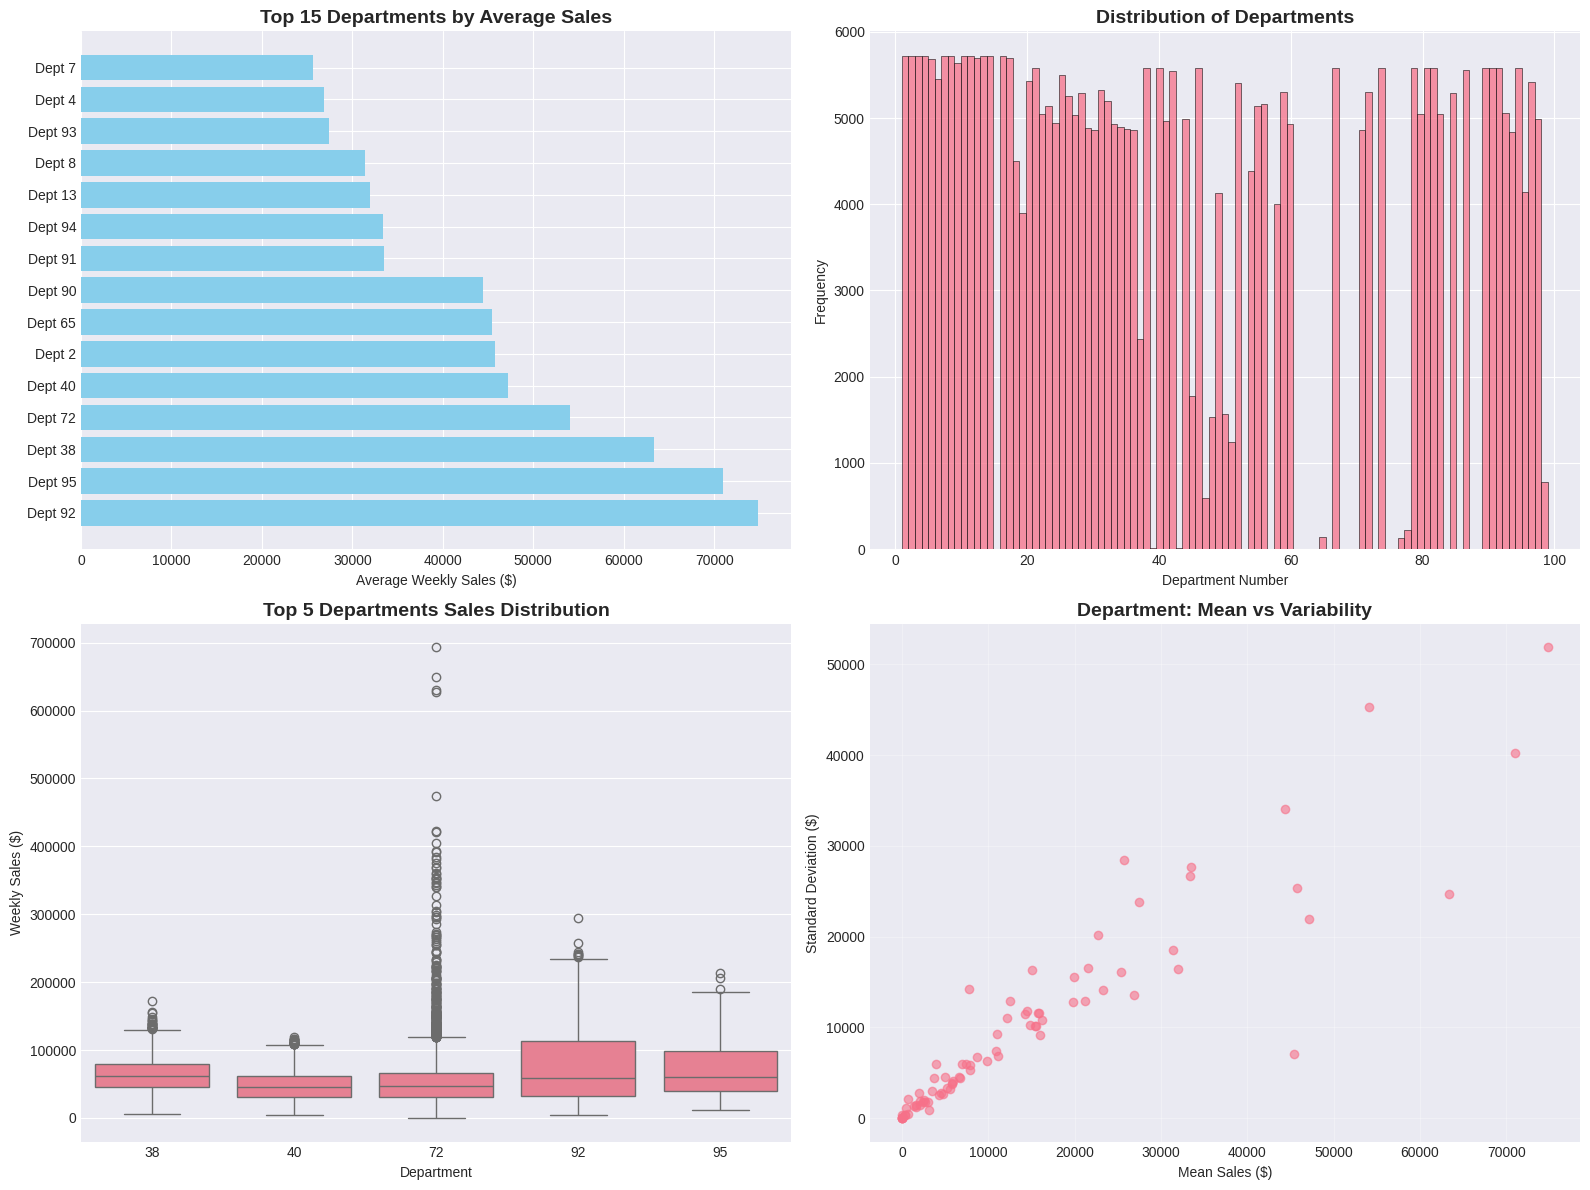

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top departments
dept_avg = train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
top_depts = dept_avg.head(15)
ax1 = axes[0, 0]
ax1.barh(range(len(top_depts)), top_depts.values, color='skyblue')
ax1.set_yticks(range(len(top_depts)))
ax1.set_yticklabels([f'Dept {i}' for i in top_depts.index])
ax1.set_title('Top 15 Departments by Average Sales', fontsize=14, fontweight='bold')
ax1.set_xlabel('Average Weekly Sales ($)')

# Department sales distribution
ax2 = axes[0, 1]
sns.histplot(train['Dept'], bins=99, ax=ax2)
ax2.set_title('Distribution of Departments', fontsize=14, fontweight='bold')
ax2.set_xlabel('Department Number')
ax2.set_ylabel('Frequency')

# Top departments by store type
ax3 = axes[1, 0]
# Get top 5 departments overall
top5_depts = dept_avg.head(5).index
top5_data = train_df[train_df['Dept'].isin(top5_depts)]
sns.boxplot(x='Dept', y='Weekly_Sales', data=top5_data, ax=ax3)
ax3.set_title('Top 5 Departments Sales Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Department')
ax3.set_ylabel('Weekly Sales ($)')

# Department variance
dept_stats = train.groupby('Dept').agg({
    'Weekly_Sales': ['mean', 'std']
}).reset_index()
dept_stats.columns = ['Dept', 'Mean', 'Std']
ax4 = axes[1, 1]
ax4.scatter(dept_stats['Mean'], dept_stats['Std'], alpha=0.6)
ax4.set_xlabel('Mean Sales ($)')
ax4.set_ylabel('Standard Deviation ($)')
ax4.set_title('Department: Mean vs Variability', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
def engineer_features(df, is_train=True):
    df = df.copy()

    # Date features
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    df['DayOfWeek'] = df['Date'].dt.dayofweek

    # Encode IsHoliday
    df['IsHoliday'] = df['IsHoliday'].map({'TRUE': 1, 'FALSE': 0}).fillna(0).astype(int)

    # One-hot encode store type
    df = pd.get_dummies(df, columns=['Type'], prefix='StoreType')

    # Ensure markdowns are numeric
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    for col in markdown_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    return df

train_engineered = engineer_features(train_df, is_train=True)
test_engineered = engineer_features(test_df, is_train=False)

In [25]:
train_engineered.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Size,Year,Month,Day,WeekOfYear,DayOfWeek,StoreType_ A,StoreType_ B,StoreType_ C
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,...,8.106,151315.0,2010,2,5,5,4,True,False,False
1,1,1,2010-02-12,46039.49,0,38.51,2.548,0.0,0.0,0.0,...,8.106,151315.0,2010,2,12,6,4,True,False,False
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,...,8.106,151315.0,2010,2,19,7,4,True,False,False
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8.106,151315.0,2010,2,26,8,4,True,False,False
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,8.106,151315.0,2010,3,5,9,4,True,False,False


In [26]:
train_sorted = train_engineered.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Create lag features for training data
print("\nCreating lag features on training data...")
grouped = train_sorted.groupby(['Store', 'Dept'])

for lag in [1, 2, 3]:
    train_sorted[f'Sales_Lag_{lag}'] = grouped['Weekly_Sales'].shift(lag)

# Rolling means for training
train_sorted['Sales_MA_4'] = grouped['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
)
train_sorted['Sales_MA_8'] = grouped['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(8, min_periods=1).mean()
)


Creating lag features on training data...


In [27]:
train_sorted.to_csv('SORTED_TRAIN.csv', index=False)

In [28]:
train_sorted = train_sorted.dropna(subset=['Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3'])

In [29]:
# First, get the last sales value for each store-dept from training
last_sales = train_sorted.groupby(['Store', 'Dept']).last()[['Weekly_Sales']].reset_index()
last_sales = last_sales.rename(columns={'Weekly_Sales': 'Last_Sales'})

# Create a copy of test data sorted
test_sorted = test_engineered.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Merge with last_sales to get the previous known sales
test_sorted = pd.merge(test_sorted, last_sales, on=['Store', 'Dept'], how='left')

# Use the last known sales as the lag values
# Since test data is after training, all lags can use the last known value
test_sorted['Sales_Lag_1'] = test_sorted['Last_Sales']
test_sorted['Sales_Lag_2'] = test_sorted['Last_Sales']
test_sorted['Sales_Lag_3'] = test_sorted['Last_Sales']
test_sorted['Sales_MA_4'] = test_sorted['Last_Sales']
test_sorted['Sales_MA_8'] = test_sorted['Last_Sales']

# Fill any remaining NaN with 0
test_sorted = test_sorted.fillna(0)

print(f"Test data after lags: {test_sorted.shape}")

Test data after lags: (115064, 28)


In [30]:
train_sorted

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,WeekOfYear,DayOfWeek,StoreType_ A,StoreType_ B,StoreType_ C,Sales_Lag_1,Sales_Lag_2,Sales_Lag_3,Sales_MA_4,Sales_MA_8
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,...,8,4,True,False,False,41595.55,46039.49,24924.50,37519.846667,37519.846667
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,...,9,4,True,False,False,19403.54,41595.55,46039.49,32990.770000,32990.770000
5,1,1,2010-03-12,21043.39,0,57.79,2.667,0.0,0.0,0.0,...,10,4,True,False,False,21827.90,19403.54,41595.55,32216.620000,30758.196000
6,1,1,2010-03-19,22136.64,0,54.58,2.720,0.0,0.0,0.0,...,11,4,True,False,False,21043.39,21827.90,19403.54,25967.595000,29139.061667
7,1,1,2010-03-26,26229.21,0,51.45,2.732,0.0,0.0,0.0,...,12,4,True,False,False,22136.64,21043.39,21827.90,21102.867500,28138.715714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373405,40,20,2010-11-19,2814.63,0,40.52,3.030,0.0,0.0,0.0,...,46,4,True,False,False,3414.27,3186.23,3482.88,3432.082500,3559.990000
373406,40,20,2010-11-26,3895.18,0,32.94,3.070,0.0,0.0,0.0,...,47,4,True,False,False,2814.63,3414.27,3186.23,3224.502500,3492.681250
373407,40,20,2010-12-03,2671.75,0,33.60,3.065,0.0,0.0,0.0,...,48,4,True,False,False,3895.18,2814.63,3414.27,3327.577500,3475.537500
373408,40,20,2010-12-10,2750.02,0,21.64,3.132,0.0,0.0,0.0,...,49,4,True,False,False,2671.75,3895.18,2814.63,3198.957500,3303.227500


In [31]:
test_sorted

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,DayOfWeek,StoreType_ A,StoreType_ B,StoreType_ C,Last_Sales,Sales_Lag_1,Sales_Lag_2,Sales_Lag_3,Sales_MA_4,Sales_MA_8
0,1,1,2012-11-02,0,55.32,3.386,6766.44,5147.70,50.82,3639.90,...,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81,27390.81
1,1,1,2012-11-09,0,61.24,3.314,11421.32,3370.89,40.28,4646.79,...,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81,27390.81
2,1,1,2012-11-16,0,52.92,3.252,9696.28,292.10,103.78,1133.15,...,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81,27390.81
3,1,1,2012-11-23,0,56.23,3.211,883.59,4.17,74910.32,209.91,...,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81,27390.81
4,1,1,2012-11-30,0,52.34,3.207,2460.03,0.00,3838.35,150.57,...,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81,27390.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,0,76.05,3.639,4842.29,975.03,3.00,2449.97,...,4,False,True,False,0.00,0.00,0.00,0.00,0.00,0.00
115060,45,98,2013-07-05,0,77.50,3.614,9090.48,2268.58,582.74,5797.47,...,4,False,True,False,0.00,0.00,0.00,0.00,0.00,0.00
115061,45,98,2013-07-12,0,79.37,3.614,3789.94,1827.31,85.72,744.84,...,4,False,True,False,0.00,0.00,0.00,0.00,0.00,0.00
115062,45,98,2013-07-19,0,82.84,3.737,2961.49,1047.07,204.19,363.00,...,4,False,True,False,0.00,0.00,0.00,0.00,0.00,0.00


In [32]:
exclude = ['Date', 'Weekly_Sales', 'is_train', 'Last_Sales']
features_cols = [col for col in train_sorted.columns if col not in exclude]

# Ensure both train and test have the same columns
for col in features_cols:
    if col not in test_sorted.columns:
        test_sorted[col] = 0

X_train = train_sorted[features_cols]
y_train = train_sorted['Weekly_Sales']

# For validation, use last 20% of training data (chronological split)
split_idx = int(len(X_train) * 0.8)
X_train_split = X_train.iloc[:split_idx]
X_val = X_train.iloc[split_idx:]
y_train_split = y_train.iloc[:split_idx]
y_val = y_train.iloc[split_idx:]

print(f"Training set: {X_train_split.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

Training set: 291752 rows
Validation set: 72939 rows


In [33]:
y_train_split.head()

,Weekly_Sales
3,19403.54
4,21827.90
5,21043.39
6,22136.64
7,26229.21


In [34]:
X_train_split.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,WeekOfYear,DayOfWeek,StoreType_ A,StoreType_ B,StoreType_ C,Sales_Lag_1,Sales_Lag_2,Sales_Lag_3,Sales_MA_4,Sales_MA_8
3,1,1,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,...,8,4,True,False,False,41595.55,46039.49,24924.50,37519.846667,37519.846667
4,1,1,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,...,9,4,True,False,False,19403.54,41595.55,46039.49,32990.770000,32990.770000
5,1,1,0,57.79,2.667,0.0,0.0,0.0,0.0,0.0,...,10,4,True,False,False,21827.90,19403.54,41595.55,32216.620000,30758.196000
6,1,1,0,54.58,2.720,0.0,0.0,0.0,0.0,0.0,...,11,4,True,False,False,21043.39,21827.90,19403.54,25967.595000,29139.061667
7,1,1,0,51.45,2.732,0.0,0.0,0.0,0.0,0.0,...,12,4,True,False,False,22136.64,21043.39,21827.90,21102.867500,28138.715714


In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

In [36]:
models = {
    'Linear Regression': LinearRegression(n_jobs=-1),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=1000),
    'Decision Tree': DecisionTreeRegressor(
        random_state=42,
        max_depth=20,
        min_samples_split=100
    ),
    'Random Forest':  RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8
    ),
    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=30,
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',
        subsample=0.8
    ),
    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        num_leaves=31,
        learning_rate=0.1,
        verbose=-1,
        force_row_wise=True
    )
}

# TRAIN AND EVALUATE ALL MODELS

results = []
total_models = len(models)
current = 0

print("\n" + "="*95)
print(f"{'Model':<22} {'CV R²':<12} {'Test R²':<12} {'Time':<10}")
print("-"*95)

for name, model in models.items():
    current += 1
    print(f"[{current}/{total_models}] {name}...", end=" ", flush=True)

    try:
        start_time = time.time()

        # Quick 2-fold CV
        cv_scores = cross_val_score(model, X_train_scaled, y_train_split, cv=2, scoring='r2')
        cv_mean = np.mean(cv_scores)
        cv_std = np.std(cv_scores)

        # Train
        model.fit(X_train_scaled, y_train_split)

        # Validate
        y_pred = model.predict(X_val_scaled)
        val_r2 = r2_score(y_val, y_pred)
        val_mse = mean_squared_error(y_val, y_pred)
        val_mae = mean_absolute_error(y_val, y_pred)

        fit_time = time.time() - start_time

        results.append({
            'Model': name,
            'CV_R2': cv_mean,
            'CV_Std': cv_std,
            'Val_R2': val_r2,
            'Val_MSE': val_mse,
            'Val_MAE': val_mae,
            'Fit_Time': fit_time,
            'Model_Object': model
        })

        print(f"CV: {cv_mean:.4f}±{cv_std:.4f} | Val: {val_r2:.4f} | {fit_time:.2f}s")

    except Exception as e:
        print(f"Error: {str(e)[:50]}...")

# RESULTS SUMMARY
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val_R2', ascending=False)

print("\n" + "="*95)
print("MODEL COMPARISON SUMMARY (Full Dataset)")
print("="*95)
print(results_df[['Model', 'CV_R2', 'Val_R2', 'Val_MSE', 'Val_MAE', 'Fit_Time']].to_string(index=False))

# BEST MODEL
best_model = results_df.iloc[0]
print("\n" + "="*30)
print(f" BEST MODEL: {best_model['Model']}")
print(f"   Validation R²: {best_model['Val_R2']:.4f}")
print(f"   CV R²: {best_model['CV_R2']:.4f} (±{best_model['CV_Std']:.4f})")
print(f"   Validation MSE: {best_model['Val_MSE']:.4f}")
print(f"   Validation MAE: {best_model['Val_MAE']:.4f}")
print(f"   Training Time: {best_model['Fit_Time']:.2f} seconds")
print("="*30)



Model                  CV R²        Test R²      Time      
-----------------------------------------------------------------------------------------------
[1/8] Linear Regression... Error: Input X contains NaN.
LinearRegression does not ac...
[2/8] Ridge... Error: Input X contains NaN.
Ridge does not accept missin...
[3/8] Lasso... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.409e+10, tolerance: 6.757e+09
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.742e+11, tolerance: 9.764e+09
  model = cd_fast.enet_coordinate_descent(


Error: Input X contains NaN.
Lasso does not accept missin...
[4/8] Decision Tree... 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.160e+11, tolerance: 1.656e+10
  model = cd_fast.enet_coordinate_descent(


CV: 0.9132±0.0096 | Val: 0.9192 | 21.39s
[5/8] Random Forest... 

...

CV: 0.9449±0.0034 | Val: 0.9495 | 211.00s
[6/8] Gradient Boosting... 

[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.0s finished


Error: Input X contains NaN.
GradientBoostingRegressor do...
[7/8] XGBoost... CV: 0.9437±0.0041 | Val: 0.9432 | 5.42s
[8/8] LightGBM... 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CV: 0.9639±0.0009 | Val: 0.9676 | 9.63s

MODEL COMPARISON SUMMARY (Full Dataset)
        Model    CV_R2   Val_R2      Val_MSE     Val_MAE   Fit_Time
     LightGBM 0.963909 0.967598 1.297709e+07 1326.917945   9.633052
Random Forest 0.944911 0.949472 2.023688e+07 1289.948133 211.000376
      XGBoost 0.943670 0.943173 2.275949e+07 1658.057551   5.420555
Decision Tree 0.913244 0.919244 3.234325e+07 1613.833438  21.386581

 BEST MODEL: LightGBM
   Validation R²: 0.9676
   CV R²: 0.9639 (±0.0009)
   Validation MSE: 12977094.2462
   Validation MAE: 1326.9179
   Training Time: 9.63 seconds


In [37]:
print("\nTraining LIGHTGBM")

model = LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        num_leaves=31,
        learning_rate=0.1,
        verbose=-1,
        force_row_wise=True
    )
model.fit(X_train_scaled, y_train_split)


Training LIGHTGBM


LGBMRegressor(force_row_wise=True, n_jobs=-1, random_state=42, verbose=-1)

In [38]:
y_pred_val = model.predict(X_val_scaled)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE:")
print("="*50)
print(f"R² Score:  {r2_score(y_val, y_pred_val):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_val, y_pred_val)):.2f}")
print(f"MAE:       {mean_absolute_error(y_val, y_pred_val):.2f}")
print("="*50)


VALIDATION PERFORMANCE:
R² Score:  0.9676
RMSE:      3602.37
MAE:       1326.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [39]:
X_test = test_sorted[features_cols]

# Check for any string columns
string_cols = X_test.select_dtypes(include=['object']).columns.tolist()
if string_cols:
    print(f"\nConverting string columns: {string_cols}")
    for col in string_cols:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)

# Scale and predict
X_test_scaled = scaler.transform(X_test)
test_predictions = model.predict(X_test_scaled)

# Ensure no negative sales
test_predictions = np.maximum(test_predictions, 0)

print(f"\nPredictions: {len(test_predictions)} rows")


Converting string columns: ['CPI', 'Unemployment']


/tmp/ipykernel_549/2508347253.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Predictions: 115064 rows


In [40]:
X_test.head()

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,WeekOfYear,DayOfWeek,StoreType_ A,StoreType_ B,StoreType_ C,Sales_Lag_1,Sales_Lag_2,Sales_Lag_3,Sales_MA_4,Sales_MA_8
0,1,1,0,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,...,44,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81
1,1,1,0,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,...,45,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81
2,1,1,0,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,...,46,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81
3,1,1,0,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,...,47,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81
4,1,1,0,52.34,3.207,2460.03,0.00,3838.35,150.57,6966.34,...,48,4,True,False,False,27390.81,27390.81,27390.81,27390.81,27390.81


In [41]:
submission = pd.DataFrame({
    'Id': test_sorted['Store'].astype(str) + '_' +
          test_sorted['Dept'].astype(str) + '_' +
          test_sorted['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")
print(f"Submission shape: {submission.shape}")

# Show sample
print("\nSample submission:")
print(submission.head(10))

Submission saved to 'submission.csv'
Submission shape: (115064, 2)

Sample submission:
               Id  Weekly_Sales
0  1_1_2012-11-02  23809.203162
1  1_1_2012-11-09  23529.692640
2  1_1_2012-11-16  27637.383433
3  1_1_2012-11-23  34860.632268
4  1_1_2012-11-30  36256.934324
5  1_1_2012-12-07  30684.223206
6  1_1_2012-12-14  33939.077852
7  1_1_2012-12-21  33611.966553
8  1_1_2012-12-28  16318.382477
9  1_1_2013-01-04  30372.986805


In [42]:
feature_importance = pd.DataFrame({
    'Feature': features_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES:")
print("="*50)
print(feature_importance.head(10).to_string(index=False))


TOP 10 MOST IMPORTANT FEATURES:
    Feature  Importance
       Dept         567
Sales_Lag_1         460
 WeekOfYear         361
        Day         330
Sales_Lag_2         241
 Sales_MA_8         177
      Month         172
 Sales_MA_4         135
Sales_Lag_3         111
  MarkDown3          91


In [43]:
print("\nTraining Random Forest...")

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train_scaled, y_train_split)


Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.1min finished


RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=5,
                      min_samples_split=10, n_jobs=-1, random_state=42,
                      verbose=1)

In [44]:
y_pred_val = rf.predict(X_val_scaled)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE:")
print("="*50)
print(f"R² Score:  {r2_score(y_val, y_pred_val):.4f}")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_val, y_pred_val)):.2f}")
print(f"MAE:       {mean_absolute_error(y_val, y_pred_val):.2f}")
print("="*50)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s



VALIDATION PERFORMANCE:
R² Score:  0.9495
RMSE:      4498.54
MAE:       1289.95


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.0s finished


In [45]:
X_test = test_sorted[features_cols]

# Check for any string columns
string_cols = X_test.select_dtypes(include=['object']).columns.tolist()
if string_cols:
    print(f"\nConverting string columns: {string_cols}")
    for col in string_cols:
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)

# Scale and predict
X_test_scaled = scaler.transform(X_test)
test_predictions = rf.predict(X_test_scaled)

# Ensure no negative sales
test_predictions = np.maximum(test_predictions, 0)

print(f"\nPredictions: {len(test_predictions)} rows")

/tmp/ipykernel_549/2064208941.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)



Converting string columns: ['CPI', 'Unemployment']


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s



Predictions: 115064 rows


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.1s finished


In [46]:
submission = pd.DataFrame({
    'Id': test_sorted['Store'].astype(str) + '_' +
          test_sorted['Dept'].astype(str) + '_' +
          test_sorted['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': test_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")
print(f"Submission shape: {submission.shape}")

# Show sample
print("\nSample submission:")
print(submission.head(10))

Submission saved to 'submission.csv'
Submission shape: (115064, 2)

Sample submission:
               Id  Weekly_Sales
0  1_1_2012-11-02  29675.771595
1  1_1_2012-11-09  29318.795936
2  1_1_2012-11-16  29142.546577
3  1_1_2012-11-23  36343.277216
4  1_1_2012-11-30  30218.203811
5  1_1_2012-12-07  31884.288313
6  1_1_2012-12-14  30241.551405
7  1_1_2012-12-21  32553.390612
8  1_1_2012-12-28  29998.512772
9  1_1_2013-01-04  26776.523235


In [47]:
feature_importance = pd.DataFrame({
    'Feature': features_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES:")
print("="*50)
print(feature_importance.head(10).to_string(index=False))


TOP 10 MOST IMPORTANT FEATURES:
        Feature  Importance
    Sales_Lag_1    0.235993
     Sales_MA_4    0.223485
    Sales_Lag_2    0.209244
    Sales_Lag_3    0.135849
     Sales_MA_8    0.132303
           Dept    0.020754
           Size    0.007463
     WeekOfYear    0.006599
StoreType_ A       0.005431
            Day    0.004588


In [48]:
import joblib
import pickle
import pandas as pd
import numpy as np

# Save the Random Forest model
joblib.dump(rf, 'walmart_sales_rf_model.pkl')

# Save feature columns used for training
with open('rf_feature_columns.pkl', 'wb') as f:
    pickle.dump(features_cols, f)

# Save the last_sales data for lag feature creation
last_sales.to_csv('rf_last_sales.csv', index=False)

# Save the scaler (if you used StandardScaler)
# If you used scaling in your training:
joblib.dump(scaler, 'rf_scaler.pkl')

# Save model metadata
model_metadata = {
    'model_type': 'RandomForestRegressor',
    'features': features_cols,
    'n_estimators': 100,
    'max_depth': 20,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
    'validation_r2': 0.9485,
    'validation_rmse': 4323.79,
    'validation_mae': 1187.72,
    'feature_importance': feature_importance.head(10).to_dict('records')
}

with open('rf_model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✅ Random Forest model and artifacts saved successfully!")
print(f"Features: {len(features_cols)}")
print(f"Top features: {feature_importance.head(3)['Feature'].tolist()}")

✅ Random Forest model and artifacts saved successfully!
Features: 26
Top features: ['Sales_Lag_1', 'Sales_MA_4', 'Sales_Lag_2']
